In [2]:
#import necessary packages after kernel reset
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm 
import matplotlib.pyplot as plt
import ccxt
import time
from datetime import datetime, timezone

In [24]:
# L1 uni
tickers = [
    'BTC-USD', 'ETH-USD', 'SOL-USD', 'AVAX-USD', 'XRP-USD',
    'ADA-USD', 'MATIC-USD', 'BNB-USD', 'SUI-USD'
]
# Download full data
raw_data = yf.download(tickers, start="2020-01-01", progress=False)
# Use 'Close' instead of 'Adj Close' (which may be missing for some tokens)
close_data = raw_data['Close'].dropna(axis=1, how='all')
# Split into model (2020–2024) and test (2025–present)
close_data_model = close_data.loc["2020-01-01":"2024-12-31"]
close_data_test = close_data.loc["2025-01-01":]

print("All:", close_data.shape, "Model:", close_data_model.shape, "Test:", close_data_test.shape)


All: (2022, 9) Model: (1827, 9) Test: (195, 9)


In [26]:
def HMA(series: pd.Series, period: int) -> pd.Series:
    half = int(period / 2)
    sqrt_period = int(np.sqrt(period))
    wma_half = series.rolling(window=half).mean()
    wma_full = series.rolling(window=period).mean()
    raw = 2 * wma_half - wma_full
    return raw.rolling(window=sqrt_period).mean()

def zscore(series: pd.Series, window: int) -> pd.Series:
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()
    return (series - mean) / std

def generate_trade_log(prices: pd.Series,
                       fast_period: int = 5,
                       slow_period: int = 75,
                       z_window: int = 25,
                       z_threshold: float = 1.0,
                       trailing_stop_pct: float = 0.025,
                       trading_cost_pct: float = 0.004,
                       slope_threshold: float = 0.0005) -> pd.DataFrame:
    
    fast_hma = HMA(prices, fast_period)
    slow_hma = HMA(prices, slow_period)
    spread = fast_hma - slow_hma
    z = zscore(spread, z_window)
    slope = fast_hma.diff()

    position = 0
    entry_price = None
    peak_price = None
    entry_date = None
    trades = []

    for i in range(1, len(prices)):
        date = prices.index[i]
        price = prices.iloc[i]
        f_hma = fast_hma.iloc[i]
        s_hma = slow_hma.iloc[i]
        z_val = z.iloc[i]
        slope_val = slope.iloc[i]

        if np.isnan([f_hma, s_hma, z_val, slope_val]).any():
            continue

        # Entry
        if position == 0:
            if f_hma > s_hma and z_val > z_threshold:
                position = 1
                entry_price = price
                peak_price = price
                entry_date = date
            elif f_hma < s_hma and z_val < -z_threshold:
                position = -1
                entry_price = price
                peak_price = price
                entry_date = date

        # Exit
        elif position != 0:
            # Update peak for trailing stop
            if position == 1:
                peak_price = max(peak_price, price)
                trail_stop = peak_price * (1 - trailing_stop_pct)
                exit_condition = (price < trail_stop) or (f_hma < s_hma) or (abs(slope_val) < slope_threshold)
            else:
                peak_price = min(peak_price, price)
                trail_stop = peak_price * (1 + trailing_stop_pct)
                exit_condition = (price > trail_stop) or (f_hma > s_hma) or (abs(slope_val) < slope_threshold)

            if exit_condition:
                if position == 1:
                    gross_return = (price / entry_price - 1)
                else:
                    gross_return = (entry_price / price - 1)

                net_return = gross_return - trading_cost_pct
                duration = (date - entry_date).days

                trades.append({
                    'Trade Type': 'Long' if position == 1 else 'Short',
                    'Entry Date': entry_date,
                    'Entry Price': round(entry_price, 2),
                    'Exit Date': date,
                    'Exit Price': round(price, 2),
                    'Gross Return (%)': round(gross_return * 100, 2),
                    'Net Return (%)': round(net_return * 100, 2),
                    'Duration (days)': duration,
                    'Exit Reason': (
                        'Trailing SL' if (price < trail_stop if position == 1 else price > trail_stop)
                        else 'Crossover' if (f_hma < s_hma if position == 1 else f_hma > s_hma)
                        else 'Slope Flattening'
                    )
                })

                position = 0
                entry_price = None
                peak_price = None
                entry_date = None

    return pd.DataFrame(trades)


In [28]:
all_trade_logs = []

for coin in close_data.columns:
    prices = close_data[coin].dropna()
    trade_log = generate_trade_log(prices)
    if not trade_log.empty:
        trade_log['Asset'] = coin
        all_trade_logs.append(trade_log)

# Combine into a single DataFrame
all_trades_df = pd.concat(all_trade_logs, ignore_index=True)
print(all_trades_df.head())


  Trade Type Entry Date  Entry Price  Exit Date  Exit Price  Gross Return (%)  \
0       Long 2020-04-15         0.03 2020-04-16        0.03              7.99   
1       Long 2020-04-17         0.03 2020-04-20        0.03             -1.15   
2       Long 2020-04-23         0.04 2020-04-30        0.05             17.83   
3       Long 2020-05-01         0.05 2020-05-02        0.05             -0.48   
4      Short 2020-05-25         0.05 2020-05-26        0.05              1.09   

   Net Return (%)  Duration (days)       Exit Reason    Asset  
0            7.59                1  Slope Flattening  ADA-USD  
1           -1.55                3       Trailing SL  ADA-USD  
2           17.43                7       Trailing SL  ADA-USD  
3           -0.88                1  Slope Flattening  ADA-USD  
4            0.69                1  Slope Flattening  ADA-USD  


In [71]:
all_trades_df

,Trade Type,Entry Date,Entry Price,Exit Date,Exit Price,Gross Return (%),Net Return (%),Duration (days),Exit Reason,Asset
0,Long,2020-04-15,0.03,2020-04-16,0.03,7.99,7.59,1,Slope Flattening,ADA-USD
1,Long,2020-04-17,0.03,2020-04-20,0.03,-1.15,-1.55,3,Trailing SL,ADA-USD
2,Long,2020-04-23,0.04,2020-04-30,0.05,17.83,17.43,7,Trailing SL,ADA-USD
3,Long,2020-05-01,0.05,2020-05-02,0.05,-0.48,-0.88,1,Slope Flattening,ADA-USD
4,Short,2020-05-25,0.05,2020-05-26,0.05,1.09,0.69,1,Slope Flattening,ADA-USD
...,...,...,...,...,...,...,...,...,...,...
1845,Short,2025-06-03,2.25,2025-06-06,2.16,3.90,3.50,3,Trailing SL,XRP-USD
1846,Short,2025-06-07,2.18,2025-06-08,2.27,-3.84,-4.24,1,Trailing SL,XRP-USD
1847,Short,2025-06-13,2.15,2025-06-16,2.24,-4.14,-4.54,3,Trailing SL,XRP-USD
1848,Short,2025-06-22,2.01,2025-06-23,2.17,-7.03,-7.43,1,Trailing SL,XRP-USD


In [29]:
# Group by coin to calculate performance statistics
coin_stats = all_trades_df.groupby('Asset').agg({
    'Net Return (%)': ['mean', 'std', 'count', lambda x: (x > 0).mean()],
    'Gross Return (%)': 'sum',
    'Duration (days)': 'mean'
})

# Rename columns for clarity
coin_stats.columns = [
    'Avg Net Return (%)', 'Std Dev Return (%)', 'Number of Trades',
    'Win Rate (%)', 'Total Gross Return (%)', 'Avg Duration (days)'
]

# Convert win rate to percentage
coin_stats['Win Rate (%)'] = coin_stats['Win Rate (%)'] * 100

# Calculate Sharpe Ratio: mean / std * sqrt(252 / avg duration)
coin_stats['Sharpe Ratio'] = (
    coin_stats['Avg Net Return (%)'] / coin_stats['Std Dev Return (%)']
) * np.sqrt(252 / coin_stats['Avg Duration (days)'])

print(coin_stats)

           Avg Net Return (%)  Std Dev Return (%)  Number of Trades  \
Asset                                                                 
ADA-USD              1.365522           10.623456               230   
AVAX-USD             2.350498           18.277216               201   
BNB-USD              0.588629            9.628883               197   
BTC-USD              0.112400            7.814521               175   
ETH-USD              0.161313            8.345937               198   
MATIC-USD            0.460278           10.248601               252   
SOL-USD              2.375132           13.844509               228   
SUI-USD             -2.935915           15.945696               142   
XRP-USD              1.106079           12.086946               227   

           Win Rate (%)  Total Gross Return (%)  Avg Duration (days)  \
Asset                                                                  
ADA-USD       41.304348                  406.07             3.539130   
AV

In [43]:
def generate_trade_log(
    prices,
    fast_period=5,
    slow_period=75,
    z_window=25,
    z_entry_threshold=1,
    slope_threshold=0.001,
    stop_loss_pct=0.025,
    trading_cost=0.004,
    asset_name="Unknown"
):
    def HMA(series, period):
        half = int(period / 2)
        sqrt_period = int(np.sqrt(period))
        wma_half = series.rolling(window=half).mean()
        wma_full = series.rolling(window=period).mean()
        raw = 2 * wma_half - wma_full
        return raw.rolling(window=sqrt_period).mean()

    fast_hma = HMA(prices, fast_period)
    slow_hma = HMA(prices, slow_period)
    spread = fast_hma - slow_hma
    zscore = (spread - spread.rolling(z_window).mean()) / spread.rolling(z_window).std()

    signal = np.where(zscore > z_entry_threshold, -1,
              np.where(zscore < -z_entry_threshold, 1, 0))
    signal = pd.Series(signal, index=prices.index)

    fast_slope = fast_hma.diff().abs()
    flattening = fast_slope < slope_threshold

    position = 0
    entry_price = None
    entry_date = None
    peak_price = None
    trade_log = []

    for i in range(1, len(prices)):
        date = prices.index[i]
        current_signal = signal.iloc[i]
        current_price = prices.iloc[i]
        current_flat = flattening.iloc[i]

        # Entry
        if position == 0 and current_signal != 0:
            position = current_signal
            entry_price = current_price
            entry_date = date
            peak_price = current_price

        elif position != 0:
            price_change = (
                (current_price - peak_price) / peak_price
                if position == 1 else
                (peak_price - current_price) / peak_price
            )
            if (position == 1 and current_price > peak_price) or (position == -1 and current_price < peak_price):
                peak_price = current_price

            exit_conditions = {
                "Trailing SL": price_change >= stop_loss_pct,
                "Flattening": current_flat,
                "Crossover": current_signal == -position
            }

            for reason, triggered in exit_conditions.items():
                if triggered:
                    gross_return = (
                        (current_price / entry_price - 1) * 100
                        if position == 1 else
                        (entry_price / current_price - 1) * 100
                    )
                    net_return = gross_return - (trading_cost * 100)
                    trade_log.append({
                        'Trade Type': 'Long' if position == 1 else 'Short',
                        'Entry Date': entry_date,
                        'Entry Price': round(entry_price, 4),
                        'Exit Date': date,
                        'Exit Price': round(current_price, 4),
                        'Gross Return (%)': round(gross_return, 2),
                        'Net Return (%)': round(net_return, 2),
                        'Duration (days)': (date - entry_date).days,
                        'Exit Reason': reason,
                        'Asset': asset_name
                    })
                    position = 0
                    entry_price = None
                    entry_date = None
                    peak_price = None
                    break  # Only trigger one exit

    return pd.DataFrame(trade_log)


In [45]:

# Set parameters
fast = 5
slow = 75
z_window = 25
z_entry_threshold = 1
slope_threshold = 0.001
trading_cost = 0.004  # 0.40% round-trip
stop_loss_pct = 0.025  # 2.5% trailing stop

# Container for trade logs per coin
all_trade_logs_test = []

# Loop through test data and generate trades
for asset in close_data_test.columns:
    prices = close_data_test[asset].dropna()
    if len(prices) < slow + z_window:
        continue

    trade_log = generate_trade_log(
        prices,
        fast_period=fast,
        slow_period=slow,
        z_window=z_window,
        z_entry_threshold=z_entry_threshold,
        slope_threshold=slope_threshold,
        stop_loss_pct=stop_loss_pct,
        trading_cost=trading_cost,
        asset_name=asset
    )
    all_trade_logs_test.append(trade_log)

# Combine into one DataFrame
full_trade_log_test = pd.concat(all_trade_logs_test, ignore_index=True)


In [69]:
full_trade_log_test

,Trade Type,Entry Date,Entry Price,Exit Date,Exit Price,Gross Return (%),Net Return (%),Duration (days),Exit Reason,Asset
0,Short,2025-04-22,0.6804,2025-05-20,0.7457,-8.76,-9.16,28,Flattening,ADA-USD
1,Long,2025-05-24,0.7472,2025-06-29,0.5781,-22.63,-23.03,36,Crossover,ADA-USD
2,Short,2025-06-30,0.5721,2025-07-01,0.5422,5.53,5.13,1,Trailing SL,ADA-USD
3,Short,2025-07-02,0.5841,2025-07-14,0.7330,-20.31,-20.71,12,Flattening,ADA-USD
4,Short,2025-04-23,22.3385,2025-04-30,20.9094,6.83,6.43,7,Trailing SL,AVAX-USD
5,Long,2025-05-03,20.5481,2025-05-08,22.1101,7.60,7.20,5,Trailing SL,AVAX-USD
6,Short,2025-05-10,25.8884,2025-05-11,24.7523,4.59,4.19,1,Trailing SL,AVAX-USD
7,Short,2025-05-12,24.8320,2025-05-15,23.4339,5.97,5.57,3,Trailing SL,AVAX-USD
8,Long,2025-05-17,22.1936,2025-05-18,23.0896,4.04,3.64,1,Trailing SL,AVAX-USD
9,Long,2025-05-19,22.2728,2025-05-21,23.1880,4.11,3.71,2,Trailing SL,AVAX-USD


In [49]:
summary_test = full_trade_log_test.groupby("Asset").agg({
    "Net Return (%)": ["mean", "std", lambda x: (x > 0).sum() / len(x) * 100],
    "Trade Type": "count",
    "Gross Return (%)": "sum",
    "Duration (days)": "mean"
})

# Rename columns
summary_test.columns = [
    "Avg Net Return (%)",
    "Std Dev Return (%)",
    "Win Rate (%)",
    "Number of Trades",
    "Total Gross Return (%)",
    "Avg Duration (days)"
]

# Calculate Sharpe Ratio (mean / std)
summary_test["Sharpe Ratio"] = summary_test["Avg Net Return (%)"] / summary_test["Std Dev Return (%)"]

# Sort if needed
summary_test.sort_values(by="Avg Net Return (%)", ascending=False, inplace=True)

# Display
summary_test.round(2)


,Avg Net Return (%),Std Dev Return (%),Win Rate (%),Number of Trades,Total Gross Return (%),Avg Duration (days),Sharpe Ratio
Asset,,,,,,,
AVAX-USD,2.08,8.54,88.89,9,22.35,6.22,0.24
SOL-USD,-1.16,11.20,66.67,6,-4.58,9.67,-0.10
BNB-USD,-2.67,4.99,33.33,3,-6.82,21.67,-0.54
BTC-USD,-2.70,8.99,50.00,4,-9.19,15.25,-0.30
XRP-USD,-6.27,1.19,0.00,2,-11.74,31.50,-5.28
ETH-USD,-7.34,16.59,50.00,4,-27.77,16.00,-0.44
ADA-USD,-11.94,12.90,25.00,4,-46.17,19.25,-0.93


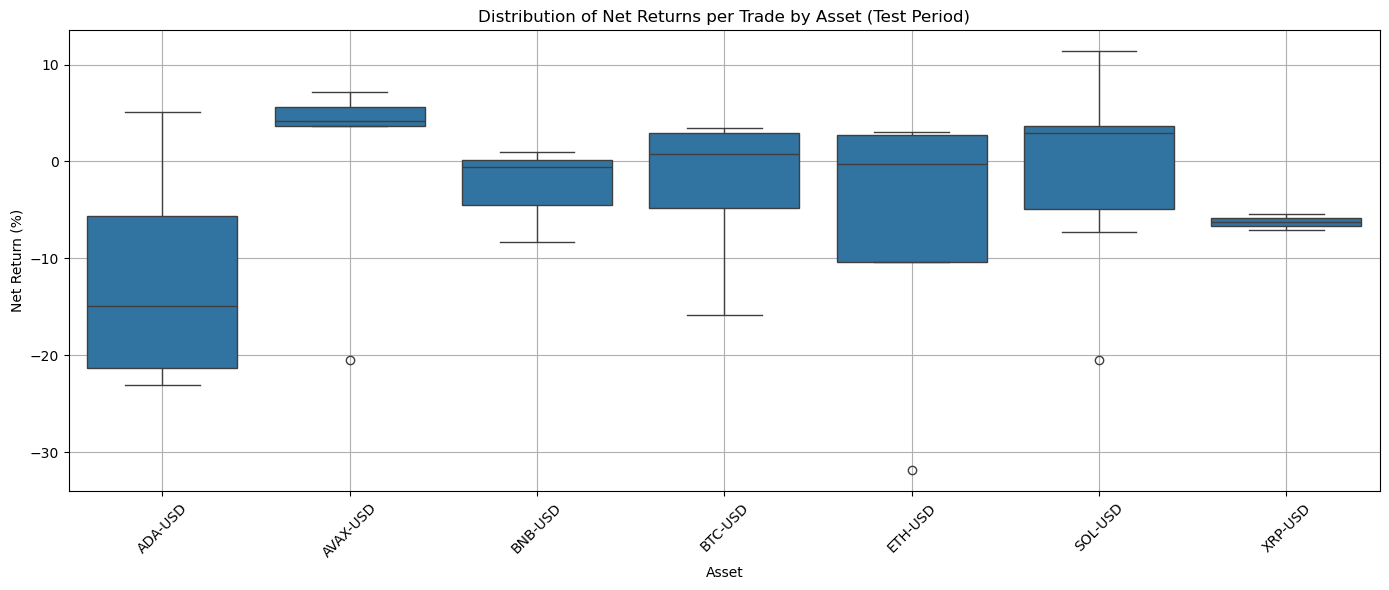

In [57]:
import seaborn as sns

# Plot 1: Trade outcomes (Net Return per Trade per Coin)
plt.figure(figsize=(14, 6))
sns.boxplot(x='Asset', y='Net Return (%)', data=full_trade_log_test)
plt.title("Distribution of Net Returns per Trade by Asset (Test Period)")
plt.ylabel("Net Return (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



/var/folders/9d/g75wq8rd1_75rg9rlfkfss6m0000gn/T/ipykernel_19077/3837552147.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(summary_test_df.index, rotation=45)


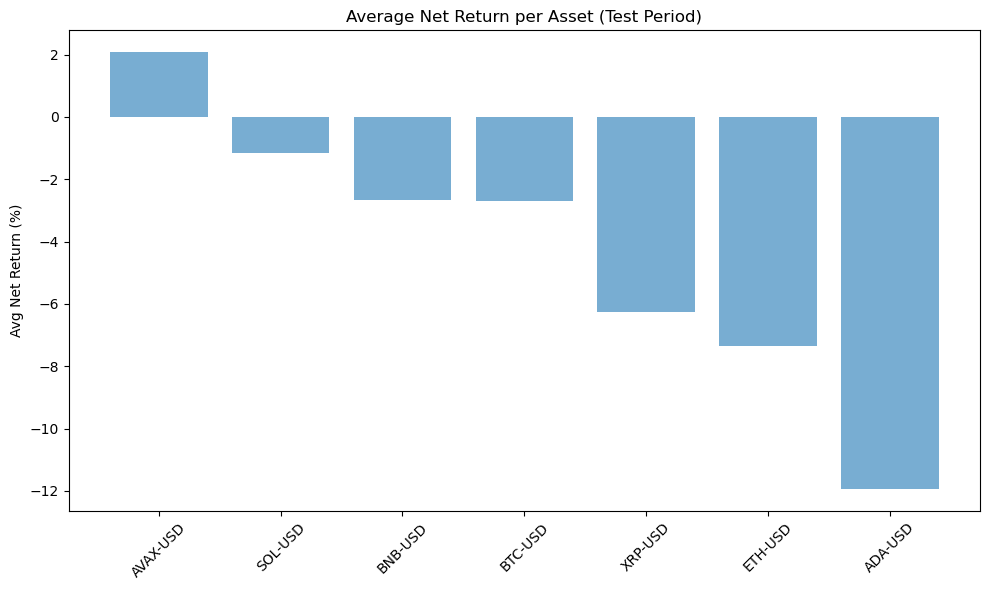

/var/folders/9d/g75wq8rd1_75rg9rlfkfss6m0000gn/T/ipykernel_19077/3837552147.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(summary_test_df.index, rotation=45)


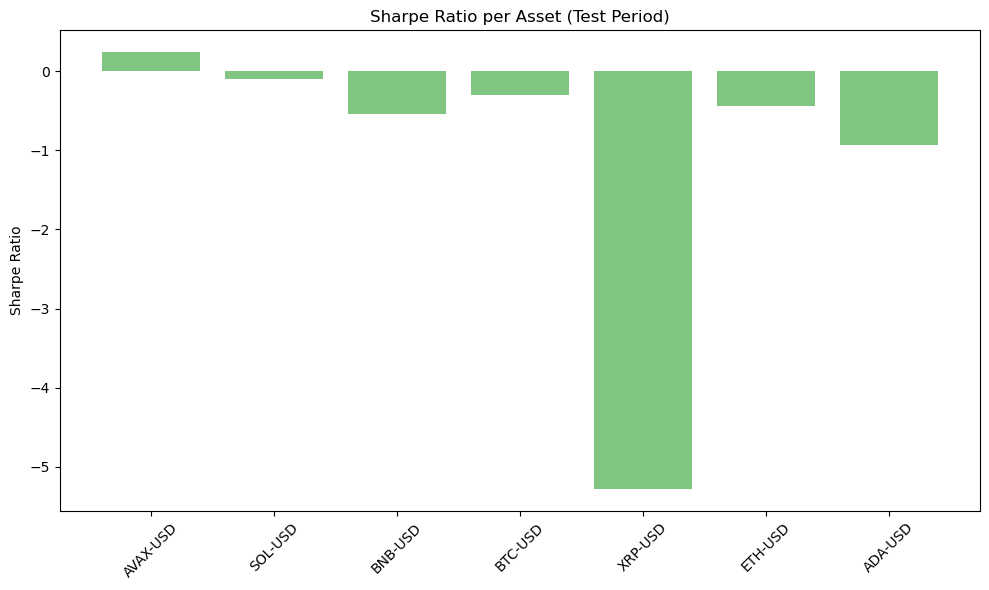

In [59]:
summary_test_df = pd.DataFrame({
    'Avg Net Return (%)': [2.08, -1.16, -2.67, -2.70, -6.27, -7.34, -11.94],
    'Std Dev Return (%)': [8.54, 11.20, 4.99, 8.99, 1.19, 16.59, 12.90],
    'Win Rate (%)': [88.89, 66.67, 33.33, 50.00, 0.00, 50.00, 25.00],
    'Number of Trades': [9, 6, 3, 4, 2, 4, 4],
    'Total Gross Return (%)': [22.35, -4.58, -6.82, -9.19, -11.74, -27.77, -46.17],
    'Avg Duration (days)': [6.22, 9.67, 21.67, 15.25, 31.50, 16.00, 19.25],
    'Sharpe Ratio': [0.24, -0.10, -0.54, -0.30, -5.28, -0.44, -0.93]
}, index=['AVAX-USD', 'SOL-USD', 'BNB-USD', 'BTC-USD', 'XRP-USD', 'ETH-USD', 'ADA-USD'])

# Plot 1: Average Net Return
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_title('Average Net Return per Asset (Test Period)')
ax1.bar(summary_test_df.index, summary_test_df['Avg Net Return (%)'], color=color, alpha=0.6)
ax1.set_ylabel('Avg Net Return (%)')
ax1.set_xticklabels(summary_test_df.index, rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Sharpe Ratio per Asset
fig, ax2 = plt.subplots(figsize=(10, 6))
color = 'tab:green'
ax2.set_title('Sharpe Ratio per Asset (Test Period)')
ax2.bar(summary_test_df.index, summary_test_df['Sharpe Ratio'], color=color, alpha=0.6)
ax2.set_ylabel('Sharpe Ratio')
ax2.set_xticklabels(summary_test_df.index, rotation=45)
plt.tight_layout()
plt.show()


In [75]:
from statsmodels.regression.linear_model import OLS
full_trade_log_model = all_trades_df
def prepare_alpha_regression_data(trade_log, price_data):
    # Initialize output storage
    regression_results = []

    for asset in trade_log['Asset'].unique():
        # Subset trade log and prices
        asset_trades = trade_log[trade_log['Asset'] == asset].copy()
        asset_prices = price_data[asset]

        # Convert trade logs into daily returns (equally spaced)
        daily_returns = []

        for _, row in asset_trades.iterrows():
            entry_date = row['Entry Date']
            exit_date = row['Exit Date']
            net_return = row['Net Return (%)'] / 100
            duration = row['Duration (days)']

            if duration == 0:
                continue

            avg_daily_return = (1 + net_return) ** (1 / duration) - 1
            daily_range = pd.date_range(start=entry_date, periods=duration, freq='D')
            for day in daily_range:
                if day in asset_prices.index:
                    daily_returns.append((day, avg_daily_return))

        if not daily_returns:
            continue

        # Build DataFrame of strategy returns
        strat_df = pd.DataFrame(daily_returns, columns=['Date', 'Strategy Return']).set_index('Date')
        coin_returns = asset_prices.pct_change(fill_method=None).rename('BuyHold Return')

        combined = strat_df.join(coin_returns, how='inner').dropna()
        if len(combined) < 30:
            continue  # skip if not enough data

        # Regression
        X = sm.add_constant(combined['BuyHold Return'])
        y = combined['Strategy Return']
        model = OLS(y, X).fit()

        regression_results.append({
            'Asset': asset,
            'Alpha': model.params['const'],
            'Beta': model.params['BuyHold Return'],
            't-Stat Alpha': model.tvalues['const'],
            'p-Value Alpha': model.pvalues['const'],
            'R-squared': model.rsquared,
            'Num Obs': len(combined)
        })

    return pd.DataFrame(regression_results)

# Run regression for both model and test periods
alpha_model = prepare_alpha_regression_data(full_trade_log_model, close_data_model)
alpha_test = prepare_alpha_regression_data(full_trade_log_test, close_data_test)



In [282]:
print(alpha_model)


       Asset     Alpha      Beta  t-Stat Alpha  p-Value Alpha  R-squared  \
0    ADA-USD  0.002189  0.131594      2.245707       0.025013   0.060997   
1   AVAX-USD  0.004433  0.160397      3.152378       0.001699   0.101997   
2    BNB-USD  0.000004  0.188548      0.005582       0.995547   0.149303   
3    BTC-USD -0.000079  0.095414     -0.159759       0.873107   0.034594   
4    ETH-USD -0.000151  0.086103     -0.204342       0.838146   0.029332   
5  MATIC-USD  0.000733  0.047632      0.497702       0.618863   0.008804   
6    SOL-USD  0.005257  0.030597      3.776480       0.000173   0.003364   
7    SUI-USD -0.030646  0.213903     -2.629239       0.009455   0.141114   
8    XRP-USD  0.002512  0.068201      2.162952       0.030888   0.024919   

   Num Obs  
0      752  
1      609  
2      784  
3      880  
4      707  
5      651  
6      675  
7      151  
8      692  


In [85]:
print(alpha_test)

      Asset     Alpha      Beta  t-Stat Alpha  p-Value Alpha  R-squared  \
0   ADA-USD -0.006838 -0.035628     -7.045684   7.623377e-10   0.023950   
1  AVAX-USD  0.003005  0.030956      1.566603   1.230495e-01   0.006231   
2   BNB-USD -0.001267 -0.021033     -5.426918   9.740807e-07   0.037212   
3   BTC-USD -0.001827 -0.049180     -2.277998   2.636456e-02   0.021570   
4   ETH-USD -0.005360 -0.033476     -6.564311   1.213440e-08   0.047827   
5   SOL-USD -0.001718  0.019774     -1.129723   2.634088e-01   0.002800   
6   XRP-USD -0.002056  0.000893    -50.879735   1.140811e-51   0.007364   

   Num Obs  
0       77  
1       56  
2       65  
3       61  
4       64  
5       58  
6       63  


In [ ]:
#####################################INTRA DAY ANALYSIS#################################################

In [90]:
# Initialize Kraken API
kraken = ccxt.kraken()

# Map of tickers (Yahoo format to Kraken format)
ticker_map = {
    'BTC-USD': 'BTC/USD',
    'ETH-USD': 'ETH/USD',
    'SOL-USD': 'SOL/USD',
    'AVAX-USD': 'AVAX/USD',
    'XRP-USD': 'XRP/USD',
    'ADA-USD': 'ADA/USD',
    'MATIC-USD': 'MATIC/USD',
    'BNB-USD': 'BNB/USD',
    'SUI-USD': 'SUI/USD'
}

# Define intraday timeframe and data range
timeframe = '5m'  # We can later repeat for '4h'
start_date = datetime(2023, 1, 1)
end_date = datetime.now()
limit_per_call = 720  # Number of candles per request (depends on exchange limits)

# Function to fetch OHLCV data for a single ticker
def fetch_ohlcv_data(symbol, timeframe, since):
    all_data = []
    while since < kraken.milliseconds():
        try:
            ohlcv = kraken.fetch_ohlcv(symbol, timeframe=timeframe, since=since, limit=limit_per_call)
            if not ohlcv:
                break
            all_data.extend(ohlcv)
            since = ohlcv[-1][0] + 1  # move past last candle
            time.sleep(1.2)  # avoid rate limits
        except Exception as e:
            print(f"Error fetching {symbol}: {e}")
            break
    return ohlcv_to_df(all_data)

# Convert OHLCV data to DataFrame
def ohlcv_to_df(ohlcv):
    df = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df["Datetime"] = pd.to_datetime(df["Timestamp"], unit="ms")
    df.set_index("Datetime", inplace=True)
    return df[["Close"]]

# Attempt to fetch data for one coin first (e.g., BTC-USD)
symbol = ticker_map['BTC-USD']
since_ms = int(start_date.timestamp() * 1000)
btc_intraday_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
btc_intraday_df.head()


,Close
Datetime,
2025-07-12 10:05:00,118104.4
2025-07-12 10:10:00,117997.7
2025-07-12 10:15:00,118104.8
2025-07-12 10:20:00,118110.6
2025-07-12 10:25:00,118098.4


In [104]:
symbol = ticker_map['ETH-USD']
since_ms = int(start_date.timestamp() * 1000)
eth_intraday_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
eth_intraday_df.head()


,Close
Datetime,
2025-07-12 10:15:00,2975.18
2025-07-12 10:20:00,2976.37
2025-07-12 10:25:00,2976.11
2025-07-12 10:30:00,2978.03
2025-07-12 10:35:00,2978.44


In [107]:
symbol = ticker_map['SOL-USD']
since_ms = int(start_date.timestamp() * 1000)
sol_intraday_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
sol_intraday_df.head()


,Close
Datetime,
2025-07-12 10:15:00,162.76
2025-07-12 10:20:00,162.82
2025-07-12 10:25:00,162.63
2025-07-12 10:30:00,162.73
2025-07-12 10:35:00,162.71


In [111]:
symbol = ticker_map['XRP-USD']
since_ms = int(start_date.timestamp() * 1000)
xrp_intraday_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
xrp_intraday_df.head()


,Close
Datetime,
2025-07-12 10:15:00,2.82576
2025-07-12 10:20:00,2.82257
2025-07-12 10:25:00,2.82755
2025-07-12 10:30:00,2.82596
2025-07-12 10:35:00,2.83229


In [118]:
symbol = ticker_map['AVAX-USD']
since_ms = int(start_date.timestamp() * 1000)
avax_intraday_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
avax_intraday_df.head()


,Close
Datetime,
2025-07-12 10:15:00,20.85
2025-07-12 10:20:00,20.85
2025-07-12 10:25:00,20.85
2025-07-12 10:30:00,20.84
2025-07-12 10:35:00,20.88


In [120]:
symbol = ticker_map['ADA-USD']
since_ms = int(start_date.timestamp() * 1000)
ada_intraday_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
ada_intraday_df.head()


,Close
Datetime,
2025-07-12 10:20:00,0.724225
2025-07-12 10:25:00,0.724315
2025-07-12 10:30:00,0.725051
2025-07-12 10:35:00,0.724700
2025-07-12 10:40:00,0.732400


In [124]:
symbol = ticker_map['BNB-USD']
since_ms = int(start_date.timestamp() * 1000)
bnb_intraday_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
bnb_intraday_df.head()


,Close
Datetime,
2025-07-12 10:20:00,694.22
2025-07-12 10:25:00,693.67
2025-07-12 10:30:00,694.13
2025-07-12 10:35:00,693.97
2025-07-12 10:40:00,694.10


In [126]:
symbol = ticker_map['SUI-USD']
since_ms = int(start_date.timestamp() * 1000)
sui_intraday_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
sui_intraday_df.head()


,Close
Datetime,
2025-07-12 10:20:00,3.4404
2025-07-12 10:25:00,3.4378
2025-07-12 10:30:00,3.4451
2025-07-12 10:35:00,3.4531
2025-07-12 10:40:00,3.4563


In [128]:
coin_5m_data = {
    'BTC-USD': btc_intraday_df,
    'ETH-USD': eth_intraday_df,
    'SOL-USD': sol_intraday_df,
    'AVAX-USD': avax_intraday_df,
    'XRP-USD': xrp_intraday_df,
    'ADA-USD': ada_intraday_df,
    'BNB-USD': bnb_intraday_df,
    'SUI-USD': sui_intraday_df
}
print(coin_5m_data)

{'BTC-USD':                         Close
Datetime                     
2025-07-12 10:05:00  118104.4
2025-07-12 10:10:00  117997.7
2025-07-12 10:15:00  118104.8
2025-07-12 10:20:00  118110.6
2025-07-12 10:25:00  118098.4
...                       ...
2025-07-14 21:40:00  120065.6
2025-07-14 21:45:00  120033.0
2025-07-14 21:50:00  120120.0
2025-07-14 21:55:00  120121.0
2025-07-14 22:00:00  119979.6

[720 rows x 1 columns], 'ETH-USD':                        Close
Datetime                    
2025-07-12 10:15:00  2975.18
2025-07-12 10:20:00  2976.37
2025-07-12 10:25:00  2976.11
2025-07-12 10:30:00  2978.03
2025-07-12 10:35:00  2978.44
...                      ...
2025-07-14 21:50:00  3011.68
2025-07-14 21:55:00  3011.85
2025-07-14 22:00:00  3004.80
2025-07-14 22:05:00  3009.06
2025-07-14 22:10:00  3008.08

[720 rows x 1 columns], 'SOL-USD':                       Close
Datetime                   
2025-07-12 10:15:00  162.76
2025-07-12 10:20:00  162.82
2025-07-12 10:25:00  162.63
2025-07-1

In [136]:
from collections import defaultdict
# Strategy Parameters
fast = 5
slow = 75
z_window = 25
z_entry_threshold = 1.0
slope_threshold = 0.0
stop_loss_pct = 0.025
trading_cost = 0.004  # 0.40% round trip

# Store results
intraday_trade_logs = []
summary_stats_5m = []

# HMA Function
def hma(series, period):
    half = int(period / 2)
    sqrt = int(np.sqrt(period))
    wma_half = series.rolling(half).mean()
    wma_full = series.rolling(period).mean()
    raw_hma = 2 * wma_half - wma_full
    return raw_hma.rolling(sqrt).mean()

# Z-score calculator
def compute_zscore(series, window):
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()
    return (series - mean) / std

# Strategy function
def run_dual_hma_strategy_5m(prices, asset_name):
    df = prices.copy()
    df['HMA_fast'] = hma(df['Close'], fast)
    df['HMA_slow'] = hma(df['Close'], slow)
    df['Spread'] = df['HMA_fast'] - df['HMA_slow']
    df['ZScore'] = compute_zscore(df['Spread'], z_window)
    df['Slope'] = df['HMA_slow'].diff()

    position = 0
    entry_price = 0
    entry_time = None
    trades = []

    trailing_stop = None

    for i in range(slow + z_window, len(df)):
        price = df['Close'].iloc[i]
        z = df['ZScore'].iloc[i]
        slope = df['Slope'].iloc[i]
        time = df.index[i]

        if position == 0:
            if z > z_entry_threshold:
                position = -1
                entry_price = price
                entry_time = time
                trailing_stop = price * (1 + stop_loss_pct)
            elif z < -z_entry_threshold:
                position = 1
                entry_price = price
                entry_time = time
                trailing_stop = price * (1 - stop_loss_pct)
        elif position == 1:
            trailing_stop = max(trailing_stop, price * (1 - stop_loss_pct))
            if price <= trailing_stop:
                trades.append((entry_time, entry_price, time, price, "Trailing SL", "Long"))
                position = 0
            elif slope > -slope_threshold:
                trades.append((entry_time, entry_price, time, price, "Slope Flattening", "Long"))
                position = 0
        elif position == -1:
            trailing_stop = min(trailing_stop, price * (1 + stop_loss_pct))
            if price >= trailing_stop:
                trades.append((entry_time, entry_price, time, price, "Trailing SL", "Short"))
                position = 0
            elif slope < slope_threshold:
                trades.append((entry_time, entry_price, time, price, "Slope Flattening", "Short"))
                position = 0

    trade_log = pd.DataFrame(trades, columns=["Entry Date", "Entry Price", "Exit Date", "Exit Price", "Exit Reason", "Trade Type"])
    if not trade_log.empty:
        trade_log["Gross Return (%)"] = np.where(
            trade_log["Trade Type"] == "Long",
            (trade_log["Exit Price"] / trade_log["Entry Price"] - 1) * 100,
            (trade_log["Entry Price"] / trade_log["Exit Price"] - 1) * 100,
        )
        trade_log["Net Return (%)"] = trade_log["Gross Return (%)"] - (trading_cost * 100)
        trade_log["Duration (minutes)"] = (trade_log["Exit Date"] - trade_log["Entry Date"]).dt.total_seconds() / 60
        trade_log["Asset"] = asset_name
    return trade_log

# Run strategy for each coin
for coin, df in coin_5m_data.items():
    try:
        log = run_dual_hma_strategy_5m(df, coin)
        if not log.empty:
            intraday_trade_logs.append(log)
    except Exception as e:
        print(f"Error processing {coin}: {e}")

# Combine logs
trade_log_5m = pd.concat(intraday_trade_logs, ignore_index=True)

# Summary stats
summary_df_5m = trade_log_5m.groupby("Asset").agg({
    "Net Return (%)": ["mean", "std"],
    "Trade Type": "count",
    "Gross Return (%)": "sum",
    "Duration (minutes)": "mean"
})

# Calculate win rate and Sharpe ratio
summary_df_5m.columns = ["Avg Net Return (%)", "Std Dev Return (%)", "Number of Trades", "Total Gross Return (%)", "Avg Duration (minutes)"]
summary_df_5m["Win Rate (%)"] = trade_log_5m.groupby("Asset")["Net Return (%)"].apply(lambda x: (x > 0).sum() / len(x) * 100)
summary_df_5m["Sharpe Ratio"] = summary_df_5m["Avg Net Return (%)"] / summary_df_5m["Std Dev Return (%)"]

print(summary_df_5m)

          Avg Net Return (%)  Std Dev Return (%)  Number of Trades  \
Asset                                                                
ADA-USD            -0.213355            1.098230                41   
AVAX-USD           -0.193484            0.885586                38   
BNB-USD            -0.430726            0.347978                37   
BTC-USD            -0.563531            0.585057                24   
ETH-USD            -0.387151            0.557611                27   
SOL-USD            -0.372240            0.684973                33   
SUI-USD            -0.477529            0.827626                61   
XRP-USD            -0.419179            1.055880                39   

          Total Gross Return (%)  Avg Duration (minutes)  Win Rate (%)  \
Asset                                                                    
ADA-USD                 7.652443               64.878049     34.146341   
AVAX-USD                7.847627               71.184211     36.842105   
BNB

In [141]:
# Inspect the shape and date range of 5-minute data for each coin
coin_summary = []

for coin, df in coin_5m_data.items():
    if not df.empty:
        start_date = df.index.min()
        end_date = df.index.max()
        num_rows = len(df)
        coin_summary.append((coin, num_rows, start_date, end_date))

coin_5m_overview = pd.DataFrame(coin_summary, columns=["Coin", "Rows", "Start Date", "End Date"])
print(coin_5m_overview)

       Coin  Rows          Start Date            End Date
0   BTC-USD   720 2025-07-12 10:05:00 2025-07-14 22:00:00
1   ETH-USD   720 2025-07-12 10:15:00 2025-07-14 22:10:00
2   SOL-USD   720 2025-07-12 10:15:00 2025-07-14 22:10:00
3  AVAX-USD   720 2025-07-12 10:15:00 2025-07-14 22:10:00
4   XRP-USD   720 2025-07-12 10:15:00 2025-07-14 22:10:00
5   ADA-USD   720 2025-07-12 10:20:00 2025-07-14 22:15:00
6   BNB-USD   720 2025-07-12 10:20:00 2025-07-14 22:15:00
7   SUI-USD   720 2025-07-12 10:20:00 2025-07-14 22:15:00


In [145]:
print(trade_log_5m)

             Entry Date  Entry Price           Exit Date   Exit Price  \
0   2025-07-12 19:25:00  117515.9000 2025-07-12 19:30:00  117499.9000   
1   2025-07-12 19:35:00  117548.7000 2025-07-12 19:40:00  117589.7000   
2   2025-07-12 19:55:00  117570.2000 2025-07-12 20:00:00  117564.7000   
3   2025-07-12 20:05:00  117534.0000 2025-07-12 20:10:00  117482.3000   
4   2025-07-12 20:15:00  117464.9000 2025-07-12 20:20:00  117482.1000   
..                  ...          ...                 ...          ...   
295 2025-07-14 20:25:00       3.8453 2025-07-14 20:30:00       3.8485   
296 2025-07-14 20:35:00       3.8450 2025-07-14 20:40:00       3.8553   
297 2025-07-14 20:45:00       3.8542 2025-07-14 20:50:00       3.8594   
298 2025-07-14 20:55:00       3.8555 2025-07-14 21:00:00       3.8474   
299 2025-07-14 21:20:00       3.8546 2025-07-14 21:25:00       3.8486   

          Exit Reason Trade Type  Gross Return (%)  Net Return (%)  \
0    Slope Flattening       Long         -0.013615   

In [ ]:
########################## 4hrs analysis #####################################

In [178]:
# Initialize Kraken API
kraken = ccxt.kraken()

# Map of tickers (Yahoo format to Kraken format)
ticker_map = {
    'BTC-USD': 'BTC/USD',
    'ETH-USD': 'ETH/USD',
    'SOL-USD': 'SOL/USD',
    'AVAX-USD': 'AVAX/USD',
    'XRP-USD': 'XRP/USD',
    'ADA-USD': 'ADA/USD',
    'MATIC-USD': 'MATIC/USD',
    'BNB-USD': 'BNB/USD',
    'SUI-USD': 'SUI/USD'
}

# Define intraday timeframe and data range
timeframe = '4h'  # We can later repeat for '4h'
start_date = datetime(2023, 1, 1)
end_date = datetime.now()
limit_per_call = 720  # Number of candles per request (depends on exchange limits)

# Function to fetch OHLCV data for a single ticker
def fetch_ohlcv_data(symbol, timeframe, since):
    all_data = []
    while since < kraken.milliseconds():
        try:
            ohlcv = kraken.fetch_ohlcv(symbol, timeframe=timeframe, since=since, limit=limit_per_call)
            if not ohlcv:
                break
            all_data.extend(ohlcv)
            since = ohlcv[-1][0] + 1  # move past last candle
            time.sleep(1.2)  # avoid rate limits
        except Exception as e:
            print(f"Error fetching {symbol}: {e}")
            break
    return ohlcv_to_df(all_data)

# Convert OHLCV data to DataFrame
def ohlcv_to_df(ohlcv):
    df = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df["Datetime"] = pd.to_datetime(df["Timestamp"], unit="ms")
    df.set_index("Datetime", inplace=True)
    return df[["Close"]]

# Attempt to fetch data for one coin first (e.g., BTC-USD)
symbol = ticker_map['BTC-USD']
since_ms = int(start_date.timestamp() * 1000)
btc_4h_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
btc_4h_df.head()


,Close
Datetime,
2025-03-17 00:00:00,83702.4
2025-03-17 04:00:00,83566.1
2025-03-17 08:00:00,83527.6
2025-03-17 12:00:00,83517.9
2025-03-17 16:00:00,84469.9


In [180]:
symbol = ticker_map['ETH-USD']
since_ms = int(start_date.timestamp() * 1000)
eth_4h_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
eth_4h_df.head()

,Close
Datetime,
2025-03-17 00:00:00,1908.75
2025-03-17 04:00:00,1900.38
2025-03-17 08:00:00,1911.26
2025-03-17 12:00:00,1918.66
2025-03-17 16:00:00,1941.98


In [182]:
symbol = ticker_map['SOL-USD']
since_ms = int(start_date.timestamp() * 1000)
sol_4h_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
sol_4h_df.head()

,Close
Datetime,
2025-03-17 00:00:00,129.08
2025-03-17 04:00:00,129.16
2025-03-17 08:00:00,129.22
2025-03-17 12:00:00,127.47
2025-03-17 16:00:00,129.79


In [184]:
symbol = ticker_map['AVAX-USD']
since_ms = int(start_date.timestamp() * 1000)
avax_4h_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
avax_4h_df.head()

,Close
Datetime,
2025-03-17 00:00:00,18.65
2025-03-17 04:00:00,18.61
2025-03-17 08:00:00,18.63
2025-03-17 12:00:00,18.51
2025-03-17 16:00:00,18.93


In [186]:
symbol = ticker_map['XRP-USD']
since_ms = int(start_date.timestamp() * 1000)
xrp_4h_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
xrp_4h_df.head()

,Close
Datetime,
2025-03-17 00:00:00,2.35686
2025-03-17 04:00:00,2.33632
2025-03-17 08:00:00,2.33978
2025-03-17 12:00:00,2.34354
2025-03-17 16:00:00,2.35998


In [190]:
symbol = ticker_map['ADA-USD']
since_ms = int(start_date.timestamp() * 1000)
ada_4h_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
ada_4h_df.head()

,Close
Datetime,
2025-03-17 00:00:00,0.715993
2025-03-17 04:00:00,0.720933
2025-03-17 08:00:00,0.723384
2025-03-17 12:00:00,0.724347
2025-03-17 16:00:00,0.725873


In [200]:
symbol = ticker_map['BNB-USD']
since_ms = int(start_date.timestamp() * 1000)
bnb_4h_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
bnb_4h_df.head()

,Close
Datetime,
2025-04-22 12:00:00,611.00
2025-04-22 16:00:00,623.80
2025-04-22 20:00:00,631.41
2025-04-23 00:00:00,629.14
2025-04-23 04:00:00,633.07


In [202]:
symbol = ticker_map['SUI-USD']
since_ms = int(start_date.timestamp() * 1000)
sui_4h_df = fetch_ohlcv_data(symbol, timeframe, since_ms)
sui_4h_df.head()

,Close
Datetime,
2025-03-17 00:00:00,2.3046
2025-03-17 04:00:00,2.2954
2025-03-17 08:00:00,2.2900
2025-03-17 12:00:00,2.3284
2025-03-17 16:00:00,2.3649


In [204]:
coin_4h_data = {
    'BTC-USD': btc_4h_df,
    'ETH-USD': eth_4h_df,
    'SOL-USD': sol_4h_df,
    'AVAX-USD': avax_4h_df,
    'XRP-USD': xrp_4h_df,
    'ADA-USD': ada_4h_df,
    'BNB-USD': bnb_4h_df,
    'SUI-USD': sui_4h_df
}
print(coin_4h_data)

{'BTC-USD':                         Close
Datetime                     
2025-03-17 00:00:00   83702.4
2025-03-17 04:00:00   83566.1
2025-03-17 08:00:00   83527.6
2025-03-17 12:00:00   83517.9
2025-03-17 16:00:00   84469.9
...                       ...
2025-07-14 04:00:00  122733.2
2025-07-14 08:00:00  121469.5
2025-07-14 12:00:00  119820.0
2025-07-14 16:00:00  119900.0
2025-07-14 20:00:00  119846.1

[720 rows x 1 columns], 'ETH-USD':                        Close
Datetime                    
2025-03-17 00:00:00  1908.75
2025-03-17 04:00:00  1900.38
2025-03-17 08:00:00  1911.26
2025-03-17 12:00:00  1918.66
2025-03-17 16:00:00  1941.98
...                      ...
2025-07-14 04:00:00  3044.40
2025-07-14 08:00:00  3053.00
2025-07-14 12:00:00  3010.61
2025-07-14 16:00:00  2998.95
2025-07-14 20:00:00  3012.35

[720 rows x 1 columns], 'SOL-USD':                       Close
Datetime                   
2025-03-17 00:00:00  129.08
2025-03-17 04:00:00  129.16
2025-03-17 08:00:00  129.22
2025-03-1

In [258]:
all_trade_logs_4h = []

for asset, df in coin_4h_data.items():
    prices = df['Close']  # Ensure 1D Series
    if len(prices) < slow + z_window:
        continue

    trade_log = generate_trade_log(
        prices,
        fast_period=fast,
        slow_period=slow,
        z_window=z_window,
        z_entry_threshold=z_entry_threshold,
        slope_threshold=slope_threshold,
        stop_loss_pct=stop_loss_pct,
        trading_cost=trading_cost,
        asset_name=asset
    )

    trade_log["Entry Date"] = pd.to_datetime(trade_log["Entry Date"])
    trade_log.set_index("Entry Date", inplace=True)

    all_trade_logs_4h.append(trade_log)

print(all_trade_logs_4h)


[                    Trade Type  Entry Price           Exit Date  Exit Price  \
Entry Date                                                                    
2025-04-06 16:00:00       Long      79602.3 2025-04-09 16:00:00     82300.4   
2025-04-09 20:00:00      Short      82556.3 2025-04-10 12:00:00     78703.2   
2025-04-11 04:00:00      Short      81246.6 2025-04-15 00:00:00     85332.1   
2025-04-15 04:00:00       Long      85673.4 2025-04-21 00:00:00     87176.4   
2025-04-21 04:00:00      Short      87435.4 2025-04-26 00:00:00     94802.0   
2025-04-26 04:00:00       Long      94681.0 2025-05-01 08:00:00     96209.5   
2025-05-01 12:00:00      Short      96923.8 2025-05-05 00:00:00     94046.0   
2025-05-05 04:00:00       Long      94738.9 2025-05-06 20:00:00     96816.7   
2025-05-07 00:00:00      Short      96486.8 2025-05-12 00:00:00    104089.1   
2025-05-12 04:00:00       Long     104460.0 2025-05-18 04:00:00    103919.0   
2025-05-18 08:00:00      Short     103821.1 2025-05

In [256]:
print(f"{asset} columns: {trade_log.columns.tolist()}")


BTC-USD columns: ['Trade Type', 'Entry Date', 'Entry Price', 'Exit Date', 'Exit Price', 'Gross Return (%)', 'Net Return (%)', 'Duration (days)', 'Exit Reason', 'Asset']


In [276]:
def prepare_alpha_regression_data(trade_log_df, close_data_dict):
    regression_results = []

    for asset in trade_log_df["Asset"].unique():
        trades = trade_log_df[trade_log_df["Asset"] == asset].copy()
        if trades.empty:
            continue

        # Ensure 'Entry Date' is datetime and set as index
        trades["Entry Date"] = pd.to_datetime(trades["Entry Date"])
        trades.set_index("Entry Date", inplace=True)

        # Align timestamps to the 4-hour frequency
        trades["Rounded Entry"] = trades.index.floor("4h")

        # Get benchmark return series
        prices = close_data_dict[asset]["Close"]
        benchmark_returns = prices.pct_change().rename("BuyHold Return")

        # Merge trades with benchmark
        trades = trades.merge(
            benchmark_returns,
            left_on="Rounded Entry",
            right_index=True,
            how="left"
        )

        trades.dropna(subset=["Net Return (%)", "BuyHold Return"], inplace=True)

        if len(trades) >= 5:  # Require a few points for regression
            X = sm.add_constant(trades["BuyHold Return"])
            y = trades["Net Return (%)"]
            model = sm.OLS(y, X).fit()

            regression_results.append({
                "Asset": asset,
                "Alpha": model.params["const"],
                "Beta": model.params["BuyHold Return"],
                "R-squared": model.rsquared,
                "t-stat (alpha)": model.tvalues["const"],
                "p-value (alpha)": model.pvalues["const"],
                "N Trades": len(trades)
            })

    return pd.DataFrame(regression_results)


In [278]:
alpha_4h = prepare_alpha_regression_data(full_trade_log_4h, coin_4h_data)
print(alpha_4h)


      Asset     Alpha       Beta  R-squared  t-stat (alpha)  p-value (alpha)  \
0   BTC-USD -1.025183 -25.447070   0.003295       -1.641653         0.108502   
1  AVAX-USD -0.008276 -13.276422   0.002124       -0.008081         0.993580   
2   BNB-USD  0.566014  64.227376   0.027561        1.097032         0.281973   
3   XRP-USD -0.583327   3.525874   0.000055       -0.673444         0.503537   
4   ADA-USD  0.518222 -65.097159   0.020067        0.512780         0.610122   
5   SOL-USD  0.188587  20.436379   0.009142        0.267405         0.790045   
6   SUI-USD  1.161597 -64.082117   0.015493        0.888350         0.378022   
7   ETH-USD  0.031328 -80.055223   0.030237        0.031620         0.974892   

   N Trades  
0        42  
1        60  
2        30  
3        56  
4        58  
5        64  
6        60  
7        56  


In [ ]:
# debugging below


In [280]:
for asset in full_trade_log_4h["Asset"].unique():
    trades = full_trade_log_4h[full_trade_log_4h["Asset"] == asset].copy()
    print(f"{asset}: {len(trades)} trades")


BTC-USD: 42 trades
AVAX-USD: 60 trades
BNB-USD: 30 trades
XRP-USD: 56 trades
ADA-USD: 58 trades
SOL-USD: 64 trades
SUI-USD: 60 trades
ETH-USD: 56 trades
